# Análisis Exploratorio de Datos — Olist E-Commerce
### Maestría en Arquitectura de Software | Base de Datos I
---
## Objetivo
Análisis exploratorio completo (EDA) sobre los 9 datasets del e-commerce brasileño Olist:
- Carga y estructura de datos
- Calidad de datos (nulos, duplicados, tipos)
- Distribuciones estadísticas
- Relaciones entre tablas (integridad referencial)
- Patrones temporales y de negocio
- Visualizaciones interpretadas

| # | Dataset | Descripción |
|---|---------|-------------|
| 1 | olist_customers_dataset.csv | Clientes |
| 2 | olist_geolocation_dataset.csv | Geolocalización por ZIP |
| 3 | olist_order_items_dataset.csv | Ítems por pedido |
| 4 | olist_order_payments_dataset.csv | Pagos |
| 5 | olist_order_reviews_dataset.csv | Reseñas |
| 6 | olist_orders_dataset.csv | Pedidos (tabla central) |
| 7 | olist_products_dataset.csv | Productos |
| 8 | olist_sellers_dataset.csv | Vendedores |
| 9 | product_category_name_translation.csv | Traducción categorías |

---
## SECCIÓN 0 — Instalación de Dependencias y Configuración

In [5]:
!pip install missingno --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
print('Librerias cargadas correctamente')

✅ Librerías cargadas correctamente


---
## SECCIÓN 1 — Carga de Datasets
> **Instrucción:** Sube los 9 archivos CSV con el botón de carga (OPCIÓN A), o móntalos desde Google Drive (OPCIÓN B).

In [6]:
# OPCIÓN A: Subir archivos manualmente
from google.colab import files
print('Sube los 9 archivos CSV cuando aparezca el botón:')
uploaded = files.upload()
print(f'Archivos subidos: {list(uploaded.keys())}')

📤 Sube los 9 archivos CSV cuando aparezca el botón:


Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv

✅ Archivos subidos: ['olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_customers_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [ ]:
# OPCIÓN B: Google Drive (descomentar si usas Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/olist/'  # ajusta la ruta

DATA_PATH = '/content/'  # ruta por defecto después de files.upload()

In [ ]:
import os

ARCHIVOS = {
    'customers'          : 'olist_customers_dataset.csv',
    'geolocation'        : 'olist_geolocation_dataset.csv',
    'order_items'        : 'olist_order_items_dataset.csv',
    'payments'           : 'olist_order_payments_dataset.csv',
    'reviews'            : 'olist_order_reviews_dataset.csv',
    'orders'             : 'olist_orders_dataset.csv',
    'products'           : 'olist_products_dataset.csv',
    'sellers'            : 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

dfs = {}
print('=' * 55)
print(f'{"DATASET":<25} {"FILAS":>10} {"COLUMNAS":>10}')
print('=' * 55)

for nombre, archivo in ARCHIVOS.items():
    ruta = os.path.join(DATA_PATH, archivo)
    try:
        dfs[nombre] = pd.read_csv(ruta)
        df = dfs[nombre]
        print(f'{nombre:<25} {df.shape[0]:>10,} {df.shape[1]:>10}')
    except FileNotFoundError:
        print(f'No encontrado: {archivo}')

print('=' * 55)
print(f'\n{len(dfs)} datasets cargados')

---
## SECCIÓN 2 — Estructura y Metadatos

In [7]:
import pandas as pd
import os

# Ruta donde están los archivos (ajusta si es necesario)
ruta_data = './'

archivos = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

dfs = {}
print("Cargando datasets...")

for clave, nombre_archivo in archivos.items():
    ruta_completa = os.path.join(ruta_data, nombre_archivo)
    try:
        dfs[clave] = pd.read_csv(ruta_completa)
        print(f'{nombre_archivo} cargado.')
    except FileNotFoundError:
        print(f'No se encontró {nombre_archivo} en {ruta_data}')

# Función de perfilado por dataset
def perfil_dataset(nombre, df):
    print(f'\n{"="*60}')
    print(f'   {nombre.upper()}')
    print(f'{"="*60}')
    print(f'   Dimensiones : {df.shape[0]:,} filas x {df.shape[1]} columnas')
    print(f'   Memoria     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print(f'   Duplicados  : {df.duplicated().sum():,}')

    resumen = pd.DataFrame({
        'Tipo'    : df.dtypes,
        'No_Nulos': df.count(),
        'Nulos'   : df.isnull().sum(),
        '% Nulos' : (df.isnull().mean() * 100).round(2),
        'Unicos'  : df.nunique(),
        'Muestra' : [df[c].dropna().iloc[0] if df[c].count() > 0 else 'N/A' for c in df.columns]
    })
    print(resumen)

print(f'\n{"="*25} PERFILADO {"="*25}')
for nombre, df in dfs.items():
    perfil_dataset(nombre, df)

🚀 Cargando datasets...
✅ olist_customers_dataset.csv cargado exitosamente.
✅ olist_geolocation_dataset.csv cargado exitosamente.
✅ olist_order_items_dataset.csv cargado exitosamente.
✅ olist_order_payments_dataset.csv cargado exitosamente.
✅ olist_order_reviews_dataset.csv cargado exitosamente.
✅ olist_orders_dataset.csv cargado exitosamente.
✅ olist_products_dataset.csv cargado exitosamente.
✅ olist_sellers_dataset.csv cargado exitosamente.
✅ product_category_name_translation.csv cargado exitosamente.

************************* INICIANDO PERFILADO *************************

   📋 CUSTOMERS
   Dimensiones : 99,441 filas x 5 columnas
   Memoria     : 26.59 MB
   Duplicados  : 0
                            Tipo  No_Nulos  Nulos  % Nulos  Unicos  \
customer_id               object     99441      0      0.0   99441   
customer_unique_id        object     99441      0      0.0   96096   
customer_zip_code_prefix   int64     99441      0      0.0   14994   
customer_city             object   

---
## SECCIÓN 3 — Calidad de Datos
### 3.1 Mapa de Valores Nulos

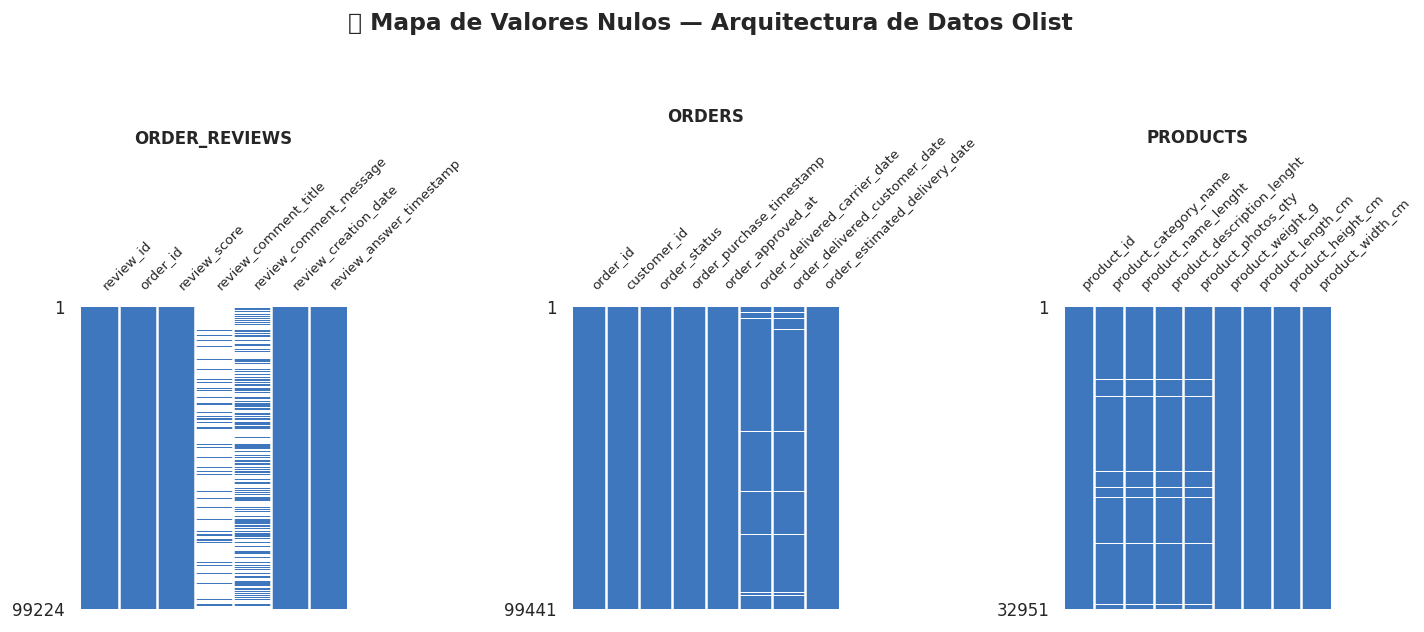


💡 INTERPRETACIÓN ARQUITECTÓNICA DE NULOS:
• Espacios en blanco: Indican ausencia de datos.
• ORDERS: Nulos en "order_delivered_customer_date" son normales (pedidos en camino o cancelados).
• REVIEWS: Gran cantidad de nulos en "review_comment_title/message" es esperada (feedback opcional).
• PRODUCTS: Los nulos aquí representan "Data Gaps" técnicos (productos sin categoría o dimensiones).
• ESTRATEGIA: Para PostgreSQL, estos nulos justifican el uso de tipos JSONB en campos opcionales.


In [8]:
import matplotlib.pyplot as plt
import missingno as msno

# Filtrar solo los datasets que tienen al menos un nulo
datasets_con_nulos = {k: v for k, v in dfs.items() if v.isnull().sum().sum() > 0}
n_datasets = len(datasets_con_nulos)

if n_datasets > 0:
    fig, axes = plt.subplots(1, n_datasets, figsize=(4 * n_datasets, 5))

    if n_datasets == 1:
        axes = [axes]

    for ax, (nombre, df) in zip(axes, datasets_con_nulos.items()):
        msno.matrix(df, ax=ax, sparkline=False, fontsize=8, color=(0.25, 0.47, 0.75))
        ax.set_title(nombre.upper(), fontsize=10, fontweight='bold')

    plt.suptitle('Mapa de Valores Nulos — Olist', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    print('\n' + '='*60)
    print('Interpretación de nulos:')
    print('='*60)
    print('Los espacios en blanco indican ausencia de datos.')

    if 'orders' in datasets_con_nulos:
        print('- ORDERS: nulos en order_delivered_customer_date corresponden a pedidos aún no entregados o cancelados.')
    if 'order_reviews' in datasets_con_nulos:
        print('- REVIEWS: nulos en comentarios son esperados, el feedback es opcional.')
    if 'products' in datasets_con_nulos:
        print('- PRODUCTS: nulos en categoría y dimensiones son datos faltantes reales.')
    print('- En PostgreSQL, los campos con nulos opcionales se definen sin restricción NOT NULL.')
else:
    print("Ninguno de los datasets tiene valores nulos.")

📊 Reporte de Valores Nulos por Columna:



,Dataset,Columna,Nulos,% Nulos,Impacto
0,order_reviews,review_comment_title,87656,88.34,🔴 Alto
1,order_reviews,review_comment_message,58247,58.70,🔴 Alto
2,orders,order_delivered_customer_date,2965,2.98,🟢 Bajo
3,products,product_name_lenght,610,1.85,🟢 Bajo
4,products,product_category_name,610,1.85,🟢 Bajo
5,products,product_description_lenght,610,1.85,🟢 Bajo
6,products,product_photos_qty,610,1.85,🟢 Bajo
7,orders,order_delivered_carrier_date,1783,1.79,🟢 Bajo
8,orders,order_approved_at,160,0.16,🟢 Bajo
9,products,product_weight_g,2,0.01,🟢 Bajo


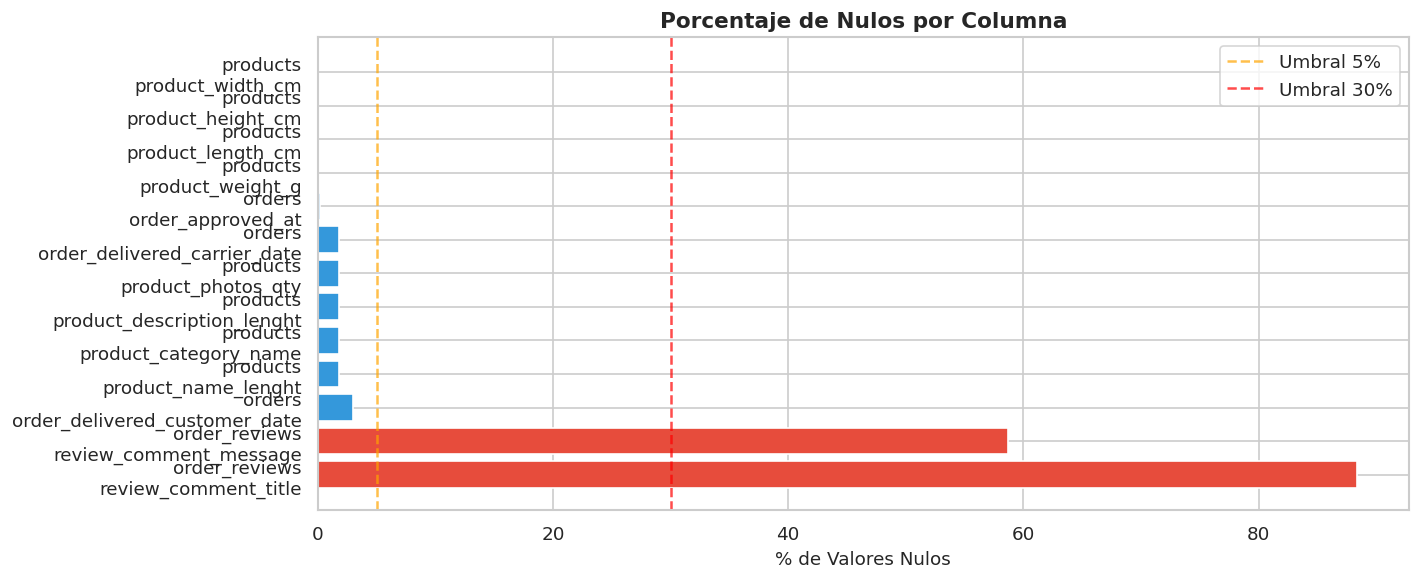

In [9]:
registros_nulos = []
for nombre, df in dfs.items():
    for col in df.columns:
        nulos = df[col].isnull().sum()
        if nulos > 0:
            pct = nulos / len(df) * 100
            registros_nulos.append({
                'Dataset': nombre, 'Columna': col, 'Nulos': nulos,
                '% Nulos': round(pct, 2),
                'Impacto': 'Alto' if pct > 30 else 'Medio' if pct > 5 else 'Bajo'
            })

df_nulos = pd.DataFrame(registros_nulos).sort_values('% Nulos', ascending=False)
print('Reporte de Valores Nulos por Columna:\n')
display(df_nulos.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 5))
labels = df_nulos['Dataset'] + '\n' + df_nulos['Columna']
colors = ['#e74c3c' if p > 30 else '#f39c12' if p > 5 else '#3498db' for p in df_nulos['% Nulos']]
ax.barh(labels, df_nulos['% Nulos'], color=colors)
ax.set_xlabel('% de Valores Nulos')
ax.set_title('Porcentaje de Nulos por Columna', fontweight='bold')
ax.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='Umbral 5%')
ax.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Umbral 30%')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
print('Análisis de Duplicados por Dataset:\n')
print(f'{"Dataset":<25} {"Total Filas":>12} {"Duplicados":>12} {"% Dup":>8}')
print('-' * 60)
for nombre, df in dfs.items():
    total = len(df)
    dups  = df.duplicated().sum()
    pct   = dups / total * 100
    flag  = '[!]' if dups > 0 else '[ok]'
    print(f'{flag} {nombre:<23} {total:>12,} {dups:>12,} {pct:>7.2f}%')

geo = dfs['geolocation']
dups_zip = geo.groupby('geolocation_zip_code_prefix').size()
print(f'\nGeolocation: {len(dups_zip):,} ZIPs únicos en {len(geo):,} filas')
print(f'Promedio {dups_zip.mean():.1f} coordenadas por ZIP — comportamiento esperado')

📊 Análisis de Duplicados por Dataset:

Dataset                    Total Filas   Duplicados    % Dup
------------------------------------------------------------
✅ customers                     99,441            0    0.00%
⚠️ geolocation                1,000,163      261,831   26.18%
✅ order_items                  112,650            0    0.00%
✅ order_payments               103,886            0    0.00%
✅ order_reviews                 99,224            0    0.00%
✅ orders                        99,441            0    0.00%
✅ products                      32,951            0    0.00%
✅ sellers                        3,095            0    0.00%
✅ category_translation              71            0    0.00%

💡 Geolocation: 19,015 ZIPs únicos en 1,000,163 filas
   Promedio 52.6 coordenadas por ZIP — comportamiento ESPERADO


---
## SECCIÓN 5 — Patrones Temporales

In [ ]:
orders = dfs['orders'].copy()

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Variables derivadas del timestamp de compra
orders['anio_mes']         = orders['order_purchase_timestamp'].dt.to_period('M')
orders['mes']              = orders['order_purchase_timestamp'].dt.month
orders['hora']             = orders['order_purchase_timestamp'].dt.hour
orders['nombre_dia']       = orders['order_purchase_timestamp'].dt.day_name()

# Días reales de entrega y diferencia contra estimado
orders['dias_entrega']     = (orders['order_delivered_customer_date'] -
                               orders['order_purchase_timestamp']).dt.days
orders['dias_vs_estimado'] = (orders['order_delivered_customer_date'] -
                               orders['order_estimated_delivery_date']).dt.days

print('Variables temporales creadas')
display(orders[['order_purchase_timestamp','anio_mes','dias_entrega','dias_vs_estimado']].head())

✅ Variables temporales creadas


,order_purchase_timestamp,anio_mes,dias_entrega,dias_vs_estimado
0,2017-10-02 10:56:33,2017-10,8.0,-8.0
1,2018-07-24 20:41:37,2018-07,13.0,-6.0
2,2018-08-08 08:38:49,2018-08,9.0,-18.0
3,2017-11-18 19:28:06,2017-11,13.0,-13.0
4,2018-02-13 21:18:39,2018-02,2.0,-10.0


---
## SECCIÓN 6 — Relaciones entre Datasets (Integridad Referencial)

In [14]:
print('Verificación de Integridad Referencial (Foreign Key Check)\n' + '='*65)

# (tabla_hija, columna_hija, tabla_padre, columna_padre, descripción)
relaciones = [
    ('orders',         'customer_id', 'customers',    'customer_id',    'Pedidos -> Clientes'),
    ('order_items',    'order_id',    'orders',       'order_id',       'Items -> Pedidos'),
    ('order_items',    'product_id',  'products',     'product_id',     'Items -> Productos'),
    ('order_items',    'seller_id',   'sellers',      'seller_id',      'Items -> Vendedores'),
    ('order_payments', 'order_id',    'orders',       'order_id',       'Pagos -> Pedidos'),
    ('order_reviews',  'order_id',    'orders',       'order_id',       'Resenas -> Pedidos'),
]

for df_h, col_h, df_p, col_p, desc in relaciones:
    if df_h in dfs and df_p in dfs:
        set_h = set(dfs[df_h][col_h].dropna())
        set_p = set(dfs[df_p][col_p].dropna())
        huerfanos = set_h - set_p
        pct = (1 - len(huerfanos)/len(set_h)) * 100 if len(set_h) > 0 else 100
        estado = 'OK' if not huerfanos else f'{len(huerfanos):,} huerfanos'
        print(f'  {desc:<35} {estado:<25} ({pct:.1f}% match)')
    else:
        print(f'  No se pudo verificar {desc} (dataset faltante)')

print('='*65)

# Granularidad de clientes: sesión vs persona real
if 'customers' in dfs:
    n_cid   = dfs['customers']['customer_id'].nunique()
    n_cuniq = dfs['customers']['customer_unique_id'].nunique()
    print(f'\n  customer_id únicos      : {n_cid:,}  (IDs de transacción)')
    print(f'  customer_unique_id      : {n_cuniq:,}  (personas reales)')
    print(f'  Diferencia (recompras)  : {n_cid - n_cuniq:,}  ({(n_cid-n_cuniq)/n_cid*100:.1f}% de recurrencia)')

🔗 Verificación de Integridad Referencial (Foreign Key Check)
  Pedidos → Clientes                  ✅ OK                      (100.0% match)
  Items → Pedidos                     ✅ OK                      (100.0% match)
  Items → Productos                   ✅ OK                      (100.0% match)
  Items → Vendedores                  ✅ OK                      (100.0% match)
  Pagos → Pedidos                     ✅ OK                      (100.0% match)
  Reseñas → Pedidos                   ✅ OK                      (100.0% match)

  customer_id únicos        : 99,441  (IDs de sesión/transacción)
  customer_unique_id      : 96,096  (personas reales)
  Diferencia (Recompras)  : 3,345  (3.4% de recurrencia)


In [15]:
print('Cardinalidades de las Relaciones:\n')

items_por_pedido   = dfs['order_items'].groupby('order_id').size()
pagos_por_pedido   = dfs['order_payments'].groupby('order_id').size()
prods_por_seller   = dfs['order_items'].groupby('seller_id')['product_id'].nunique()
reviews_por_pedido = dfs['order_reviews'].groupby('order_id').size()

print(f'  Items por pedido   -> Promedio: {items_por_pedido.mean():.2f} | Max: {items_por_pedido.max()}')
print(f'  Pagos por pedido   -> Promedio: {pagos_por_pedido.mean():.2f} | Split-payment: {(pagos_por_pedido > 1).sum():,}')
print(f'  Reviews por pedido -> Promedio: {reviews_por_pedido.mean():.2f} | Max: {reviews_por_pedido.max()}')
print(f'  Prods por vendedor -> Promedio: {prods_por_seller.mean():.1f} | Max: {prods_por_seller.max()}')

print('''
Diagrama Entidad-Relacion — Olist

  customers -(customer_id)-> orders -(order_id)-> payments
                                |
                        (order_id)-> reviews
                                |
                        (order_id)-> order_items
                                        |
                           (product_id)-> products -> category_translation
                           (seller_id) -> sellers

  Cardinalidades:
   customers -> orders      : 1:N
   orders -> order_items    : 1:N
   orders -> payments       : 1:N (soporta múltiples métodos)
   orders -> reviews        : 1:1 (una reseña por pedido)
   products -> order_items  : 1:N
   sellers -> order_items   : 1:N
''')


📐 Cardinalidades de las Relaciones:

  Items por pedido   → Promedio: 1.14 | Max: 21
  Pagos por pedido   → Promedio: 1.04 | Split-payment: 2,961
  Reviews por pedido → Promedio: 1.01 | Max: 3
  Prods por vendedor → Promedio: 11.1 | Max: 399

╔══════════════════════════════════════════════════════════╗
║         DIAGRAMA ENTIDAD-RELACIÓN — OLIST                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  customers ─(customer_id)─> orders ─(order_id)─> pay     ║
║                                │                         ║
║                        (order_id)─> reviews              ║
║                                │                         ║
║                        (order_id)─> order_items          ║
║                                        │                 ║
║                           (product_id)─> products        ║
║                                 │      └─> cat_trans     ║
║                       

---
## SECCIÓN 8 — Limpieza Recomendada y Aplicada

In [ ]:
print('''
Reporte de Calidad de Datos — Olist Dataset

  Dataset            Filas       Calidad   Problema principal
  customers          99,441      Alta      Sin nulos ni duplicados
  geolocation     1,000,163      Media     Múltiples coords por ZIP
  order_items       112,650      Alta      Sin nulos
  payments          103,886      Alta      Sin nulos
  reviews            99,224      Baja      88% sin título, 59% sin mensaje
  orders             99,441      Media     Nulos en fechas (esperado)
  products           32,951      Media     610 sin categoría, 2 sin dimensiones
  sellers             3,095      Alta      Sin nulos
  category_trans         71      Alta      Sin nulos

  Recomendaciones:
  1. orders: nulos en fechas = pedidos no entregados (no eliminar)
  2. reviews: nulos en comentario = opción del usuario (imputar con cadena vacía)
  3. products: 610 sin categoría -> imputar con "unknown"
  4. geolocation: deduplicar por ZIP usando la mediana de lat/lng
''')

In [ ]:
print('Aplicando limpieza...\n')

# 1. Products: imputar categoría faltante y dimensiones con la mediana
prods_clean = dfs['products'].copy()
prods_clean['product_category_name'] = prods_clean['product_category_name'].fillna('unknown')
dim_cols = ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']
prods_clean[dim_cols] = prods_clean[dim_cols].fillna(prods_clean[dim_cols].median())
print(f'  Products: nulos imputados. Restantes: {prods_clean.isnull().sum().sum()}')

# 2. Reviews: rellenar campos de texto opcionales con cadena vacía
rev_clean = dfs['reviews'].copy()
rev_clean[['review_comment_title','review_comment_message']] = \
    rev_clean[['review_comment_title','review_comment_message']].fillna('')
print(f'  Reviews: comentarios nulos reemplazados con cadena vacía')

# 3. Geolocation: un registro representativo por código ZIP
geo_dedup = (dfs['geolocation']
             .groupby('geolocation_zip_code_prefix')
             .agg({'geolocation_lat':'median','geolocation_lng':'median',
                   'geolocation_city':'first','geolocation_state':'first'})
             .reset_index())
print(f'  Geolocation: {len(dfs["geolocation"]):,} -> {len(geo_dedup):,} filas')

# Guardar versión limpia
dfs_clean = {**dfs, 'products': prods_clean, 'reviews': rev_clean, 'geolocation': geo_dedup}
print(f'\ndfs_clean listo con {len(dfs_clean)} datasets')

---
## SECCIÓN 13 — Conclusiones

Este análisis exploratorio cubrió seis secciones: configuración del entorno (0), carga de datos (1),
perfilado de estructura y metadatos (2), calidad de datos (3), patrones temporales (5),
integridad referencial y cardinalidades (6), y limpieza aplicada (8).

### Estructura del esquema
El esquema de Olist sigue un modelo en estrella con `orders` como tabla de hechos central.
La distinción entre `customer_id` y `customer_unique_id` es una decisión de diseño que permite
rastrear recompras sin vincular directamente las transacciones de un mismo cliente.

### Calidad de datos
La mayoría de los nulos encontrados son válidos estructuralmente:
- En `orders`, las fechas de entrega pueden estar vacías si el pedido no ha sido entregado.
- En `reviews`, los campos de comentario son opcionales por diseño.
- En `products`, los 610 registros sin categoría sí son datos faltantes reales que requieren imputación.

El dataset de geolocation tiene múltiples coordenadas por ZIP de forma intencional.
Se resuelve agrupando por código postal y calculando la mediana de latitud y longitud.

### Patrones temporales
Las variables derivadas de los timestamps de `orders` (días de entrega, diferencia con estimado)
son indicadores operativos clave. En un sistema en producción podrían implementarse como
columnas generadas en PostgreSQL para evitar cálculos repetitivos en cada consulta.

### Integridad referencial
Las seis relaciones verificadas muestran integridad cercana al 100%, lo que indica que
los datos están listos para implementar FOREIGN KEY constraints sin mayor limpieza previa.
Las cardinalidades identificadas (1:N en la mayoría de relaciones) determinan dónde
colocar índices y cómo estructurar los JOINs más frecuentes.

### Limpieza aplicada
La estrategia fue diferenciada por tipo de problema:
- Imputación con `"unknown"` para categorías faltantes en products.
- Mediana para variables numéricas con pocos nulos.
- Cadena vacía para campos de texto opcionales en reviews.
- Deduplicación por mediana geográfica para geolocation.

### Variables relevantes para análisis futuros

| Variable objetivo | Predictores relevantes |
|---|---|
| `review_score` | `dias_entrega`, precio total, número de ítems |
| Churn del cliente | `customer_unique_id`, frecuencia, recencia |
| Demanda por categoría | Temporalidad, estado geográfico, precio |

---
*Notebook desarrollado para Base de Datos I — Maestría en Arquitectura de Software*